In [1]:
import sys

from sqlalchemy.dialects.mssql.information_schema import columns
from sympy.abc import alpha

sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from collections import deque

import seaborn as sns
import matplotlib.pyplot as plt
from structure_learning.approximators import StructureMCMC
from structure_learning.data import SyntheticDataset, Data
from structure_learning.distributions import Distribution, OPAD
from structure_learning.data_structures import DAG
from structure_learning.scores import BGeScore

np.random.seed(100)

Testing new class Node - NIW_BGe_GlobalPrior_Node

In [3]:
synthetic_data = SyntheticDataset(num_nodes=5, num_obs=1500, node_labels=[chr(ord('a') + i) for i in range(5)], degree=2)
scaled_data = synthetic_data.data.standardise()


00010 00100 10000 00000 01010


In [4]:
# Implementing a new class Node - Testing

bge = BGeScore(scaled_data)
bge_result = bge.compute(synthetic_data.graph, compute_full_posterior=True)

bge_result




{'score': np.float64(-3825.9362163451156),
 'parameters': {'a': {'score': np.float64(370.8524383465166),
   'node_idx': 0,
   'parents': [2],
   'node_label': 'a',
   'parent_label': [np.str_('c')],
   'posterior': {'sigma2_shape': 752.0,
    'sigma2_scale': np.float64(26.563498709054898),
    'muN_node': np.float64(0.0),
    'muN_parents': c    2.366898e-17
    dtype: float64,
    'beta_mean': array([0.98212534]),
    'chol_parent_T': array([[38.72337795]]),
    'kappa_N': 1501}},
  'b': {'score': np.float64(-899.3083638174866),
   'node_idx': 1,
   'parents': [4],
   'node_label': 'b',
   'parent_label': [np.str_('e')],
   'posterior': {'sigma2_shape': 752.0,
    'sigma2_scale': np.float64(143.82275369914146),
    'muN_node': np.float64(0.0),
    'muN_parents': e   -2.366898e-17
    dtype: float64,
    'beta_mean': array([-0.89898409]),
    'chol_parent_T': array([[38.72337795]]),
    'kappa_N': 1501}},
  'c': {'score': np.float64(-453.7699824331238),
   'node_idx': 2,
   'parents': 

In [5]:
from structure_learning.data_structures.node import NIW_BGe_GlobalPrior_Node
target_col = 'a'
parents = synthetic_data.graph.find_parents(target_col)

niw_node = NIW_BGe_GlobalPrior_Node(
    data=scaled_data,
    parents=parents,
    target_col=target_col,
    rng=np.random.default_rng(123),
)

niw_node.fit()

In [6]:
niw_node.marginal_likelihood()

np.float64(370.8524383465262)

In [7]:
print(f'NIW node and BGeScore for node {target_col} is identical: {np.allclose(niw_node.marginal_likelihood(), bge_result['parameters'][target_col]['score'])}')

NIW node and BGeScore for node a is identical: True


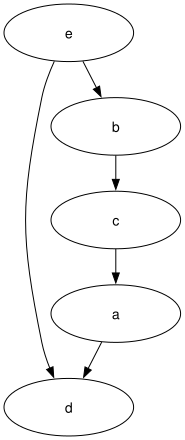

In [8]:
synthetic_data.graph.plot()


# Tests:

1. Given a DAG, how BGeScore changes with the level of missingness, and what happens to the score after missing  in the data.

|## Test 1: BGeScore with missingness
1. Single node missingness => See effect only on a leaf node
2. Single node missingness => See effect only on a root node
3. Single node missingness => See effect only on a non-leaf node
4. Multiple node missingness

In [9]:
if synthetic_data.graph.has_cycle(synthetic_data.graph):
    raise ValueError("Graph is not a DAG")
topological_order = synthetic_data.graph.topological_sort()
topological_order

['e', 'b', 'c', 'a', 'd']

In [10]:
leaf_node = topological_order[-1]



In [11]:
missing_rate = 0.1

missing_mask = np.random.rand(*(scaled_data[leaf_node].shape)) < missing_rate

simulating_data_with_missingness = scaled_data.__copy__()
simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\4218513209.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


In [12]:
simulating_data_with_missingness.values.isna().sum(axis=0)

a      0
b      0
c      0
d    140
e      0
dtype: int64

In [13]:
score_struct = BGeScore(scaled_data)
score_struct.compute(synthetic_data.graph)['score']


np.float64(-3825.9362163451156)

In [14]:
score_struct_missing = BGeScore(simulating_data_with_missingness.values.dropna())
score_struct_missing.compute(synthetic_data.graph)['score']

np.float64(-3449.860278864581)

In [15]:
# THis only work if sampling based on topological order

def sample_missing_values(
    data: Data,
    graph: DAG,
    models: dict,
    random_state=None,
):
    """
    Sample missing values from node-wise conditional models following
    the DAG's topological order.

    Existing observed values are never overwritten.

    Parameters
    ----------
    data : pd.DataFrame
        Data with columns corresponding to graph nodes.

    graph : nx.DiGraph
        Directed acyclic graph.

    models : dict
        Mapping:
            node -> fitted model

        Each model is expected to provide:
            model.sample(parent_values, rng=...)

        where parent_values is a DataFrame of shape
            (n_samples, n_parents)

        For root nodes, parent_values will have zero columns.

    random_state : int or None
        Random seed.

    Returns
    -------
    pd.DataFrame
        Copy of data with sampleable missing values filled.
    """

    if DAG.has_cycle(graph):
        # TODO: this might not be neccesary in the future if we can guarantee that the graph is a DAG.
        raise ValueError("graph must be a DAG")

    rng = np.random.default_rng(random_state)

    topo_order = graph.topological_sort()

    modified_nodes = []

    for node in topo_order:

        parents = list(graph.find_parents(node))

        # Only sampling missing data - TODO: missing data per node, should be captured in INIT - keep an empty list if no missing data so easy to continue. keep indices instead?
        missing = data[node].isna()


        if not missing.any() and not any(parent in modified_nodes for parent in parents):
            # print(f"Node {node} has no missing values. Skipping.")
            continue
        else:
            modified_nodes.append(node)

        # ------------------------------------------------------------
        # Determine which missing observations can actually be sampled
        # ------------------------------------------------------------

        if parents:
            # Parents have already been processed because we're following
            # topological order.
            parents_available = data[parents][missing].notna().all(axis=1)

            rows_to_sample = parents_available.index[parents_available]

        else:
            # Root node: no conditioning variables are required.
            rows_to_sample = data.values.index[missing]

        if len(rows_to_sample) == 0:
            continue

        # ------------------------------------------------------------
        # Sample only the required observations
        # ------------------------------------------------------------

        valid_node_data = Data(data.values[~missing], variables=data.variables)

        BGeNode = NIW_BGe_GlobalPrior_Node(
            data=valid_node_data,
            parents=parents,
            target_col=node,
            rng=rng,
        ).fit()

        samples = BGeNode.predict(data.values.loc[rows_to_sample, parents])

        # Assign only sampled values
        res = data.values.copy()
        node_idx = res.columns.get_loc(node)
        res.iloc[rows_to_sample, node_idx] = samples.flatten()


    return Data(res, variables=data.variables)


One row at a time. M = Missign, O = Observed

$X_M\mid X_O=x_O \sim N(\mu_{M|O},\Sigma_{M|O})$

$\mu_{M|O} = \mu_M+ \Sigma_{MO}\Sigma_{OO}^{-1} (x_O-\mu_O) $

$\Sigma_{M|O} = \Sigma_{MM} - \Sigma_{MO} \Sigma_{OO}^{-1}\Sigma_{OM}$

In [16]:
import numpy as np
from scipy.linalg import solve


def sample_missing_row(row, mu, Sigma, rng=None):
    """
    Jointly sample all missing values in one row from

        X_missing | X_observed

    where X ~ N(mu, Sigma).

    row, mu and Sigma must use the same variable ordering.
    """

    if rng is None:
        rng = np.random.default_rng()

    row = np.asarray(row, dtype=float).copy()

    missing = np.flatnonzero(np.isnan(row))
    observed = np.flatnonzero(~missing)

    # Nothing to impute
    if len(missing) == 0:
        return row

    # \[X_M \mid X_O=x_O \sim N(\mu_{M|O},\Sigma_{M|O})\]
    #
    mu_m = mu[missing]
    Sigma_mm = Sigma[np.ix_(missing, missing)]

    # If entire row is missing, sample from marginal
    if len(observed) == 0:
        row[missing] = rng.multivariate_normal(
            mean=mu_m,
            cov=Sigma_mm,
        )
        return row

    mu_o = mu[observed]
    x_o = row[observed]

    Sigma_mo = Sigma[np.ix_(missing, observed)]
    Sigma_oo = Sigma[np.ix_(observed, observed)]

    # K = Sigma_mo @ inv(Sigma_oo)
    # Don't explicitly invert Sigma_oo
    K = solve(
        Sigma_oo,
        Sigma_mo.T,
        assume_a="pos",
    ).T

    conditional_mean = (
        mu_m
        + K @ (x_o - mu_o)
    )

    conditional_cov = (
        Sigma_mm
        - K @ Sigma_mo.T
    )

    # Remove tiny numerical asymmetry
    conditional_cov = (
        conditional_cov + conditional_cov.T
    ) / 2

    row[missing] = rng.multivariate_normal(
        mean=conditional_mean,
        cov=conditional_cov,
    )

    return row

In [17]:
def sample_missing_values2(
    data: Data,
    graph: DAG,
    models: dict,
    random_state=None,
):
    """
    Sample missing values from node-wise conditional models following
    the DAG's topological order.

    Existing observed values are never overwritten.

    Parameters
    ----------
    data : pd.DataFrame
        Data with columns corresponding to graph nodes.

    graph : nx.DiGraph
        Directed acyclic graph.

    models : dict
        Mapping:
            node -> fitted model

        Each model is expected to provide:
            model.sample(parent_values, rng=...)

        where parent_values is a DataFrame of shape
            (n_samples, n_parents)

        For root nodes, parent_values will have zero columns.

    random_state : int or None
        Random seed.

    Returns
    -------
    pd.DataFrame
        Copy of data with sampleable missing values filled.
    """

    if DAG.has_cycle(graph):
        # TODO: this might not be neccesary in the future if we can guarantee that the graph is a DAG.
        raise ValueError("graph must be a DAG")

    rng = np.random.default_rng(random_state)

    node_order = list(data.columns)
    p = len(data.columns)
    node_order = {node: i for i, node in enumerate(node_order)}


    sigma2 = [None]*len(node_order)
    intercept = [None]*len(node_order)
    B = np.zeros((len(node_order), len(node_order)))

    # build the covariance matrix using the BGeNode for each node in the graph
    for node, i in node_order.items():

        parents = list(graph.find_parents(node))
        if parents is None:
            # Root node: no conditioning variables are required.
            columns_to_sample = [node]
        else:
            columns_to_sample = parents + [node]

        # Only sampling missing data - TODO: missing data per node, should be captured in INIT - keep an empty list if no missing data so easy to continue. keep indices instead?
        missing = data[columns_to_sample].isna().any(axis=1)

        # ------------------------------------------------------------
        # Determine which missing observations can actually be sampled
        # ------------------------------------------------------------

        valid_node_data = Data(data.values[~missing], variables=data.variables)

        BGeNode = NIW_BGe_GlobalPrior_Node(
            data=valid_node_data,
            parents=parents,
            target_col=node,
            rng=rng,
        ).fit()

        params = BGeNode.sample_parameters()

        intercept[i] = params["intercept"]
        sigma2[i] = params["sigma2"]
        for parent, beta in zip(parents, params["beta"].flatten()):
            B[node_order[parent], i] = beta

    A = np.eye(p) - B.T

    A_inv = np.linalg.solve(A, np.eye(p))

    mu = A_inv @ np.ravel(intercept)

    D = np.diag(np.ravel(sigma2))

    Sigma = A_inv @ D @ A_inv.T

    # use the mu and Sigma to sample missing values for each row in the data
 # ------------------------------------------------------------
    # Sample missing values row-by-row
    # ------------------------------------------------------------

    sampled_data = data.values.copy()

    for row_idx in range(len(sampled_data)):

        row = sampled_data.iloc[
            row_idx
        ].to_numpy(dtype=float)

        missing = np.flatnonzero(
            np.isnan(row)
        )

        if len(missing) == 0:
            continue

        sampled_data.iloc[row_idx] = sample_missing_row(row, mu, Sigma, rng=rng)

    return Data(
        sampled_data,
        variables=data.variables,
    )


In [18]:
from structure_learning.data_structures.node import NIW_BGe_GlobalPrior_Node

models = {}

for target_col in scaled_data.columns:
    parents = synthetic_data.graph.find_parents(target_col)
    niw_node = NIW_BGe_GlobalPrior_Node(
        data=scaled_data,
        parents=parents,
        target_col=target_col,
        rng=np.random.default_rng(123),
    )

    niw_node.fit()

    models[target_col] = niw_node


In [19]:
resampled_NAN_data = sample_missing_values2(simulating_data_with_missingness,  synthetic_data.graph, models)

In [20]:
resampled_NAN_data.values.isna().sum(axis=0)

a    0
b    0
c    0
d    0
e    0
dtype: int64

In [21]:
score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score']


np.float64(-3996.2803216416046)

In [22]:
type(resampled_NAN_data.values)

pandas.core.frame.DataFrame

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\1222092351.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


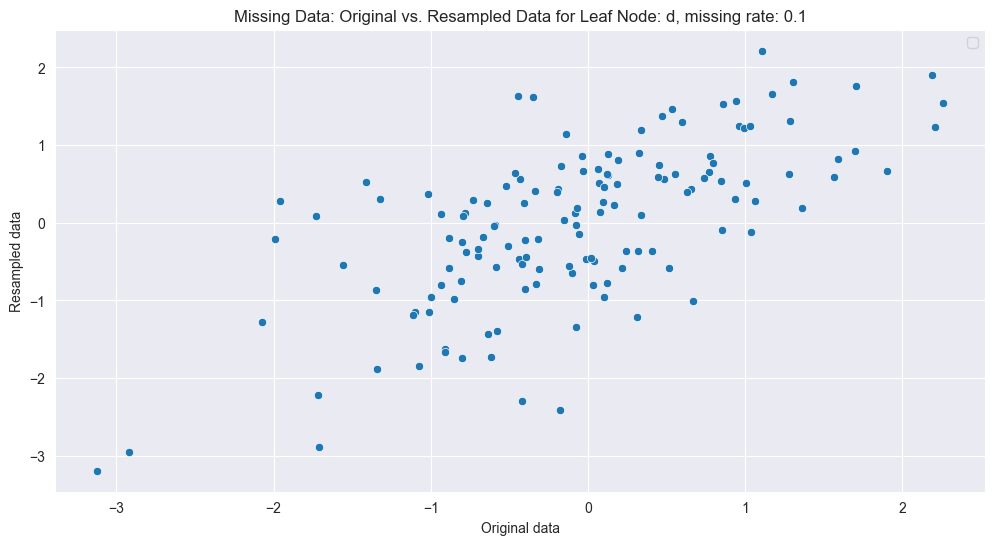

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\1222092351.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


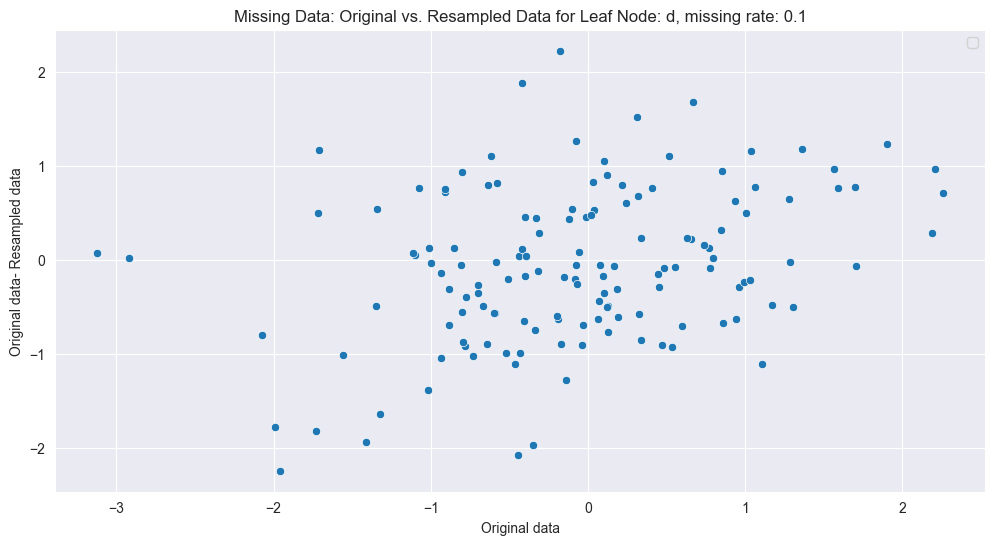

In [23]:
# histogram of the original data and the resampled data for the leaf node - not overlapping
plt.figure(figsize=(12, 6))

sns.scatterplot(x=scaled_data.values.loc[missing_mask, leaf_node], y=resampled_NAN_data.values.loc[missing_mask, leaf_node])

plt.title(f'Missing Data: Original vs. Resampled Data for Leaf Node: {leaf_node}, missing rate: {missing_rate}')
plt.xlabel('Original data')
plt.ylabel('Resampled data')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=scaled_data.values.loc[missing_mask, leaf_node],
                y=scaled_data.values.loc[missing_mask, leaf_node] - resampled_NAN_data.values.loc[missing_mask, leaf_node])

plt.title(f'Missing Data: Original vs. Resampled Data for Leaf Node: {leaf_node}, missing rate: {missing_rate}')
plt.xlabel('Original data')
plt.ylabel('Original data- Resampled data')
plt.legend()
plt.show()


In [26]:
NAN_res = []
for _ in range(1000):

    resampled_NAN_data = sample_missing_values(simulating_data_with_missingness,  synthetic_data.graph, models)
    score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
    NAN_res.append(score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score'])

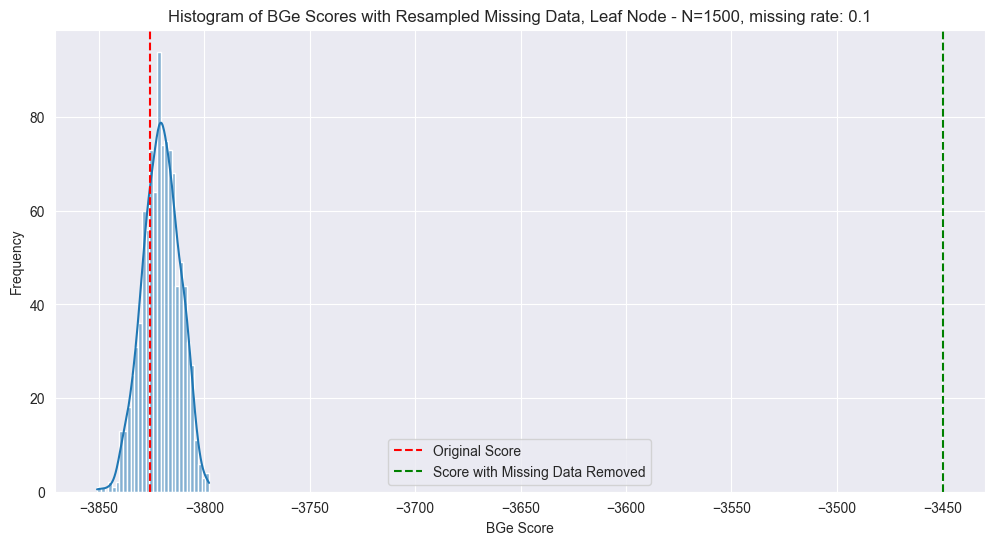

In [27]:
# plot a histogram of the scores with resampled missing data
plt.figure(figsize=(12, 6))
sns.histplot(NAN_res, bins=30, kde=True)
plt.axvline(score_struct.compute(synthetic_data.graph)['score'], color='r', linestyle='--', label='Original Score')
plt.axvline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data Removed')
plt.title(f'Histogram of BGe Scores with Resampled Missing Data, Leaf Node - N={scaled_data.shape[0]}, missing rate: {missing_rate}')
plt.xlabel('BGe Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [30]:
bge_avg = []
bge_std = []

missing_rate_vec = np.linspace(0.01, 0.5, 20)
for missing_rate in missing_rate_vec:
    print(f"Missing rate: {missing_rate:.2f}")
    missing_mask = np.random.rand(*(scaled_data[leaf_node].shape)) < missing_rate
    simulating_data_with_missingness = scaled_data.__copy__()
    simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan

    NAN_res = []
    for _ in range(1000):

        resampled_NAN_data = sample_missing_values(simulating_data_with_missingness,  synthetic_data.graph, models)
        score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
        NAN_res.append(score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score'])

    bge_avg.append(np.mean(NAN_res))
    bge_std.append(np.std(NAN_res))

Missing rate: 0.01


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.04


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.06


...

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.47


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.50


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


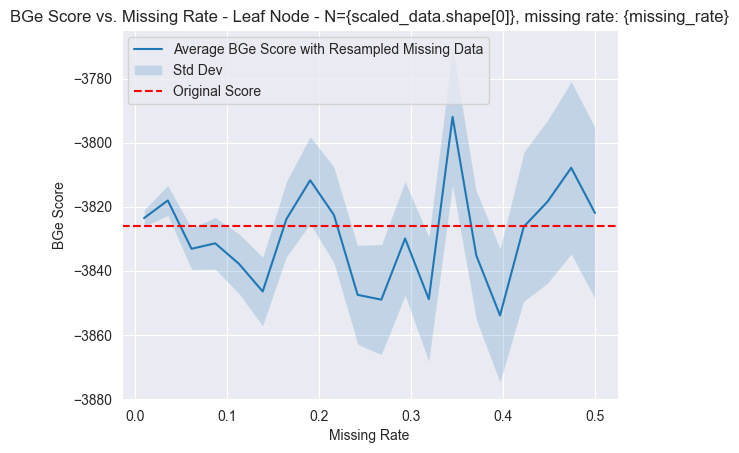

In [31]:
plt.plot(missing_rate_vec, bge_avg, label='Average BGe Score with Resampled Missing Data')
plt.fill_between(missing_rate_vec, np.array(bge_avg) - np.array(bge_std), np.array(bge_avg) + np.array(bge_std), alpha=0.2, label='Std Dev')
plt.axhline(score_struct.compute(synthetic_data.graph)['score'], color='r', linestyle='--', label='Original Score')
# plt.axhline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data')
plt.title('BGe Score vs. Missing Rate - Leaf Node - N={scaled_data.shape[0]}, missing rate: {missing_rate}')
plt.xlabel('Missing Rate')
plt.ylabel('BGe Score')
plt.legend()
plt.show()

In [32]:
# Compute posterior distribution over graphs with missing data for a root node

from structure_learning.distributions.distribution import TrueDistribution

ground_truth_distribution = TrueDistribution()

ground_truth_distribution = ground_truth_distribution.compute_distribution(data=scaled_data, score=BGeScore)

In [33]:
missing_rate = 0.1

missing_mask = np.random.rand(*(scaled_data[leaf_node].shape)) < missing_rate
simulating_data_with_missingness = scaled_data.__copy__()
simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan
resampled_NAN_data = sample_missing_values(simulating_data_with_missingness,  synthetic_data.graph, models)

resampled_data_distribution = TrueDistribution()
resampled_data_distribution = resampled_data_distribution.compute_distribution(data=resampled_NAN_data, score=BGeScore)

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\1354409854.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


In [34]:
# Compare distributions of the original data and the resampled data for the root node
#1. Compare the posterior mass of the groud truth
print(f"Ground truth with full data' = {ground_truth_distribution.particles[synthetic_data.graph.to_key()]['p']}")
print(f"Ground truth with Missing data' = {resampled_data_distribution.particles[synthetic_data.graph.to_key()]['p']}")

Ground truth with full data' = 0.12244006202701428
Ground truth with Missing data' = 0.11609846658165196


In [35]:
from structure_learning.evaluation.metrics import JSD,KLD
KLD().compute(resampled_data_distribution, ground_truth_distribution)
JSD().compute(resampled_data_distribution, ground_truth_distribution)

np.float64(0.002353645518677502)

In [41]:
bge_JSD_avg = []
bge_JSD_std = []

bge_KLD_avg = []
bge_KLD_std = []

missing_rate_vec = np.linspace(0.01, 0.5, 10)
for missing_rate in missing_rate_vec:
    print(f"Missing rate: {missing_rate:.2f}")
    missing_mask = np.random.rand(*(scaled_data[leaf_node].shape)) < missing_rate
    simulating_data_with_missingness = scaled_data.__copy__()
    simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan

    NAN_kld_res = []
    NAN_jsd_res = []
    for _ in range(1):

        resampled_NAN_data = sample_missing_values2(simulating_data_with_missingness,  synthetic_data.graph, models)
        resampled_data_distribution = TrueDistribution()
        resampled_data_distribution = resampled_data_distribution.compute_distribution(data=resampled_NAN_data, score=BGeScore)

        kld_val = KLD().compute(resampled_data_distribution, ground_truth_distribution)
        JSD_val = JSD().compute(resampled_data_distribution, ground_truth_distribution)


        NAN_kld_res.append(kld_val)
        NAN_jsd_res.append(JSD_val)

    bge_JSD_avg.append(np.mean(NAN_jsd_res))
    #bge_JSD_std.append(np.std(NAN_jsd_res))

    bge_KLD_avg.append(np.mean(NAN_kld_res))
    #bge_KLD_std.append(np.std(NAN_kld_res))



Missing rate: 0.01


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\2935390401.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.06


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\2935390401.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.12


...

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\2935390401.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.45


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\2935390401.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.50


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\2935390401.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


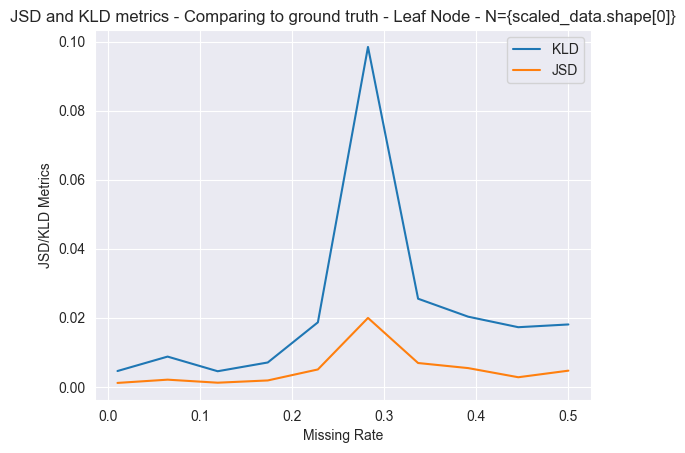

In [42]:
plt.plot(missing_rate_vec, bge_KLD_avg, label='KLD')
# plt.fill_between(missing_rate_vec, np.array(bge_KLD_avg) - np.array(bge_KLD_std), np.array(bge_KLD_avg) + np.array(bge_KLD_std), alpha=0.2, label='KLD Std Dev')
plt.plot(missing_rate_vec, bge_JSD_avg, label='JSD')
# plt.fill_between(missing_rate_vec, np.array(bge_JSD_avg) - np.array(bge_JSD_std), np.array(bge_JSD_avg) + np.array(bge_JSD_std), alpha=0.2, label='JSD Std Dev')

# plt.axhline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data')
plt.title('JSD and KLD metrics - Comparing to ground truth - Leaf Node - N={scaled_data.shape[0]}')
plt.xlabel('Missing Rate')
plt.ylabel('JSD/KLD Metrics')
plt.legend()
plt.show()

In [43]:
root_node = topological_order[0]

print(f"Root node: {root_node}")


Root node: e


In [44]:
missing_rate = 0.1
missing_mask = np.random.rand(*(scaled_data[root_node].shape)) < missing_rate
simulating_data_with_missingness = scaled_data.__copy__()
simulating_data_with_missingness.values[root_node][missing_mask] = np.nan

resampled_NAN_data = sample_missing_values2(simulating_data_with_missingness,  synthetic_data.graph, models)


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\1340820293.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3987660687.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


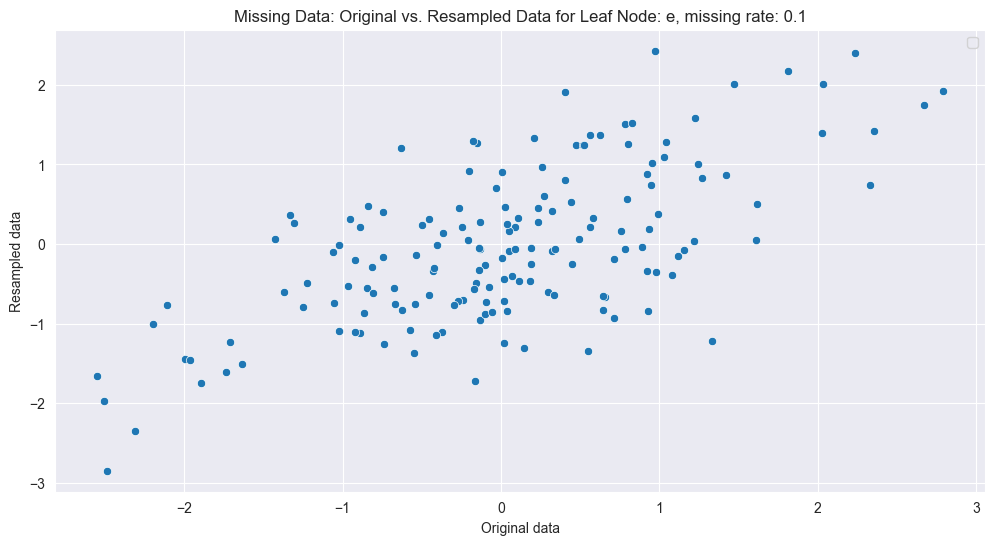

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3987660687.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


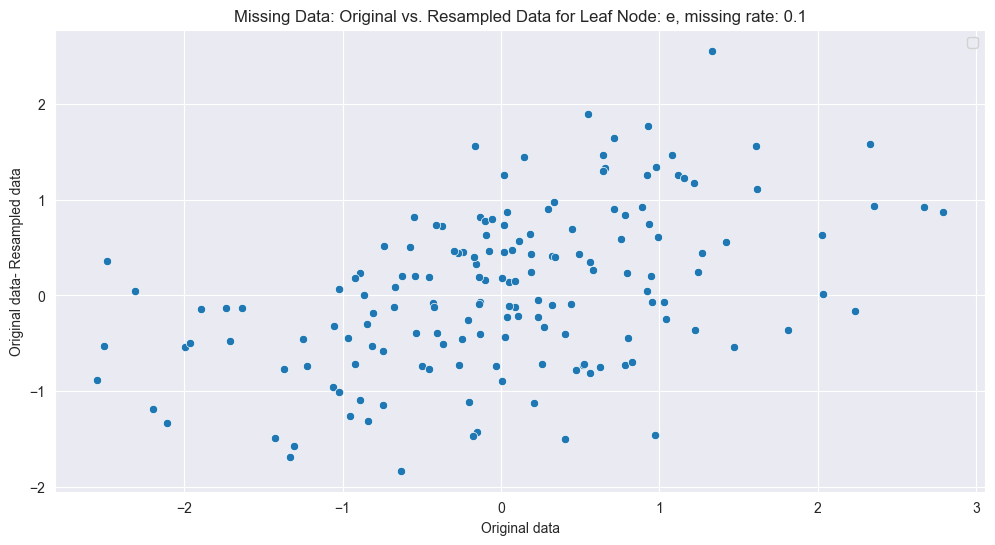

In [45]:
# histogram of the original data and the resampled data for the leaf node - not overlapping
plt.figure(figsize=(12, 6))

sns.scatterplot(x=scaled_data.values.loc[missing_mask, root_node], y=resampled_NAN_data.values.loc[missing_mask, root_node])

plt.title(f'Missing Data: Original vs. Resampled Data for Leaf Node: {root_node}, missing rate: {missing_rate}')
plt.xlabel('Original data')
plt.ylabel('Resampled data')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=scaled_data.values.loc[missing_mask, root_node],
                y=scaled_data.values.loc[missing_mask, root_node] - resampled_NAN_data.values.loc[missing_mask, root_node])

plt.title(f'Missing Data: Original vs. Resampled Data for Leaf Node: {root_node}, missing rate: {missing_rate}')
plt.xlabel('Original data')
plt.ylabel('Original data- Resampled data')
plt.legend()
plt.show()

In [46]:

bge_avg = []
bge_std = []

missing_rate_vec = np.linspace(0.01, 0.5, 20)
for missing_rate in missing_rate_vec:
    print(f"Missing rate: {missing_rate:.2f}")
    missing_mask = np.random.rand(*(scaled_data[root_node].shape)) < missing_rate
    simulating_data_with_missingness = scaled_data.__copy__()
    simulating_data_with_missingness.values[root_node][missing_mask] = np.nan

    NAN_res = []
    for _ in range(1000):

        resampled_NAN_data = sample_missing_values2(simulating_data_with_missingness,  synthetic_data.graph, models)
        score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
        NAN_res.append(score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score'])

    bge_avg.append(np.mean(NAN_res))
    bge_std.append(np.std(NAN_res))



Missing rate: 0.01


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3026025767.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.04


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3026025767.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.06


...

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3026025767.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.47


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3026025767.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.50


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3026025767.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


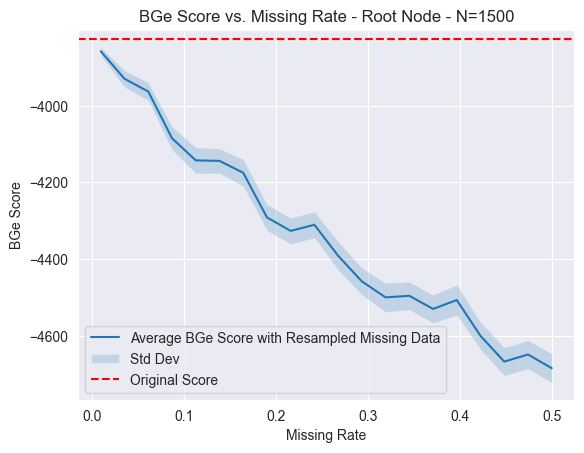

In [48]:
plt.plot(missing_rate_vec, bge_avg, label='Average BGe Score with Resampled Missing Data')
plt.fill_between(missing_rate_vec, np.array(bge_avg) - np.array(bge_std), np.array(bge_avg) + np.array(bge_std), alpha=0.2, label='Std Dev')
plt.axhline(score_struct.compute(synthetic_data.graph)['score'], color='r', linestyle='--', label='Original Score')
# plt.axhline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data')
plt.title(f'BGe Score vs. Missing Rate - Root Node - N={scaled_data.shape[0]}')
plt.xlabel('Missing Rate')
plt.ylabel('BGe Score')
plt.legend()
plt.show()

In [65]:
missing_mask = np.random.rand(*(scaled_data[root_node].shape)) < missing_rate
simulating_data_with_missingness = scaled_data.__copy__()
simulating_data_with_missingness.values[root_node][missing_mask] = np.nan

simulating_data_with_missingness.values.isna().sum(axis=0)

C:\Users\161342\AppData\Local\Temp\ipykernel_45068\3949922010.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


a      0
b      0
c      0
d      0
e    755
dtype: int64

In [49]:
# Root node - Compute posterior distribution over graphs with missing data
print(f"Posterir stability analysis for Root node: {root_node}")
bge_JSD_avg = []
bge_JSD_std = []

bge_KLD_avg = []
bge_KLD_std = []

missing_rate_vec = np.linspace(0.01, 0.5, 10)
for missing_rate in missing_rate_vec:
    print(f"Missing rate: {missing_rate:.2f}")
    missing_mask = np.random.rand(*(scaled_data[root_node].shape)) < missing_rate
    simulating_data_with_missingness = scaled_data.__copy__()
    simulating_data_with_missingness.values[root_node][missing_mask] = np.nan

    NAN_kld_res = []
    NAN_jsd_res = []
    for _ in range(1):

        resampled_NAN_data = sample_missing_values2(simulating_data_with_missingness,  synthetic_data.graph, models)
        resampled_data_distribution = TrueDistribution()
        resampled_data_distribution = resampled_data_distribution.compute_distribution(data=resampled_NAN_data, score=BGeScore)

        kld_val = KLD().compute(resampled_data_distribution, ground_truth_distribution)
        JSD_val = JSD().compute(resampled_data_distribution, ground_truth_distribution)


        NAN_kld_res.append(kld_val)
        NAN_jsd_res.append(JSD_val)

    bge_JSD_avg.append(np.mean(NAN_jsd_res))
    #bge_JSD_std.append(np.std(NAN_jsd_res))

    bge_KLD_avg.append(np.mean(NAN_kld_res))
    #bge_KLD_std.append(np.std(NAN_kld_res))


Posterir stability analysis for Root node: e
Missing rate: 0.01


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3028493851.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.06


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3028493851.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.12


...

C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3028493851.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.45


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3028493851.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


Missing rate: 0.50


C:\Users\161342\AppData\Local\Temp\ipykernel_32796\3028493851.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[root_node][missing_mask] = np.nan


In [64]:
bge_JSD_avg

[np.float64(0.5803159357562824),
 np.float64(0.5707667715852047),
 np.float64(0.5700940314952079),
 np.float64(0.5706040669849477),
 np.float64(0.571667862663993),
 np.float64(0.5731305451750739),
 np.float64(0.5700199604690521),
 np.float64(0.5707777510862153),
 np.float64(0.5730341881540519),
 np.float64(0.5731967309611133)]

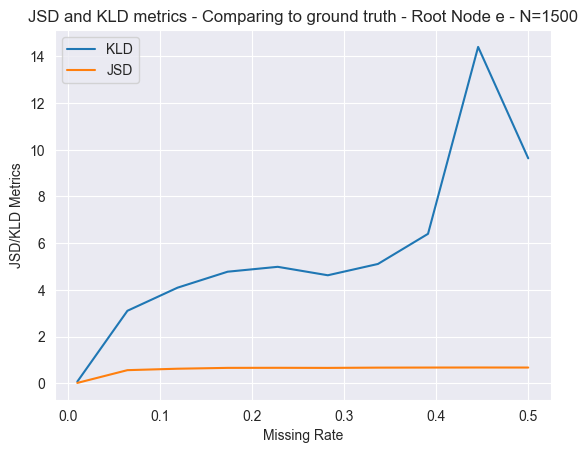

In [50]:
plt.plot(missing_rate_vec, bge_KLD_avg, label='KLD')
# plt.fill_between(missing_rate_vec, np.array(bge_KLD_avg) - np.array(bge_KLD_std), np.array(bge_KLD_avg) + np.array(bge_KLD_std), alpha=0.2, label='KLD Std Dev')
plt.plot(missing_rate_vec, bge_JSD_avg, label='JSD')
# plt.fill_between(missing_rate_vec, np.array(bge_JSD_avg) - np.array(bge_JSD_std), np.array(bge_JSD_avg) + np.array(bge_JSD_std), alpha=0.2, label='JSD Std Dev')

# plt.axhline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data')
plt.title(f'JSD and KLD metrics - Comparing to ground truth - Root Node {root_node} - N={scaled_data.shape[0]}')
plt.xlabel('Missing Rate')
plt.ylabel('JSD/KLD Metrics')
plt.legend()
plt.show()

# Posterior distribution sensitivity to missingness